# Notebook 13: Scaling Analysis

Reviewer-facing scaling notebook for pricing-family instances P3 through P7. This notebook keeps execution coverage, encoding diagnostics, and analytic resource estimates in separate provenance layers and uses the current canonical master as the ground truth for execution outcomes.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    from notebooks._helpers import repo_root, load_metrics_master, load_instance, ensure_run_status_norm, unavailable_panel_table
except ModuleNotFoundError:
    from _helpers import repo_root, load_metrics_master, load_instance, ensure_run_status_norm, unavailable_panel_table

ROOT = repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.encoding_compare import _evaluate_g_over_full_domain, _select_candidates_by_g, flatten_decision_metrics, flatten_paired_metrics_for_encoding
from src.metrics_decision import compute_decision_metrics
from src.pricing_ilp import solve_pricing_pair
from src.pricing_model_ortools import solve_pricing_with_cp_sat
from src.resources import dqi_resource_estimate

pd.set_option("display.max_columns", 120)
plt.style.use("seaborn-v0_8-whitegrid")

**Scope Note:** P3-P6 instances have full DQI statevector validation. **P7 (n=14 bits) is analytic-only** because exact statevector simulation requires 2^14 × 16 bytes ≈ 256 MB per state vector, and with syndrome/error spaces the total memory requirement exceeds typical 16GB RAM systems. P7 resource estimates are included for scaling extrapolation but have not been validated through executed DQI runs.

execution coverage comes from the canonical master.

encoding diagnostics come from frozen paired artifacts / truth-table diagnostics.

In [2]:
canonical_m_value = 15
plots_dir = ROOT / "results" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

instance_specs = globals().get("instance_specs") or {
    "P3": ROOT / "data" / "instances" / "pricing_3feat_6bit.json",
    "P4": ROOT / "data" / "instances" / "pricing_4feat_8bit.json",
    "P5": ROOT / "data" / "instances" / "pricing_5feat_10bit.json",
    "P6": ROOT / "data" / "instances" / "pricing_6feat_12bit.json",
    "P7": ROOT / "data" / "instances" / "pricing_7feat_14bit.json",
}

metrics_master_df = globals().get("metrics_master_df")
if metrics_master_df is None:
    metrics_master_df = load_metrics_master(ROOT / "results", required=False)
metrics_master_df = ensure_run_status_norm(metrics_master_df.copy()) if not metrics_master_df.empty else pd.DataFrame()
if not metrics_master_df.empty and "execution_mode" in metrics_master_df.columns and "execution_mode_norm" not in metrics_master_df.columns:
    metrics_master_df["execution_mode_norm"] = metrics_master_df["execution_mode"].astype(str).str.strip().str.lower()

instance_payloads = globals().get("instance_payloads")
benchmark_payloads = {}
for path in ROOT.glob("results/runs/**/benchmark_*feat.json"):
    try:
        payload = json.loads(path.read_text())
    except Exception:
        continue
    n_features = payload.get("problem", {}).get("n_features")
    if n_features is not None:
        benchmark_payloads[f"P{int(n_features)}"] = payload

if instance_payloads is None:
    instance_payloads = {}
    for instance_id, path in instance_specs.items():
        instance_payloads[instance_id] = json.loads(Path(path).read_text())

loaded_probs = {}
for instance_id, path in instance_specs.items():
    try:
        loaded_probs[instance_id] = load_instance(path)
    except Exception:
        loaded_probs[instance_id] = None

cp_sat_fallback = globals().get("cp_sat_fallback")
if cp_sat_fallback is None:
    def cp_sat_fallback(instance_id: str, payload: dict):
        prob = loaded_probs.get(instance_id)
        if prob is None:
            return {
                "status": "unavailable",
                "time": np.nan,
                "model_type": "unavailable",
                "n_variables": np.nan,
            }
        result = solve_pricing_with_cp_sat(prob, instance_id=instance_id)
        meta = result.get("metadata", {}) if isinstance(result, dict) else {}
        return {
            "status": result.get("status"),
            "time": result.get("time"),
            "model_type": meta.get("solver_name", result.get("solver", "ortools_cp_sat_one_hot_exact")),
            "n_variables": meta.get("n_variables", meta.get("n_decision_variables")),
        }

paired_artifacts = {}
for path in sorted((ROOT / "results" / "paired_pricing").glob("*.paired.json")):
    try:
        paired = json.loads(path.read_text())
    except Exception:
        continue
    source_id = paired.get("source_metadata", {}).get("instance_id") or paired.get("instance_id")
    if source_id:
        paired_artifacts[source_id] = paired

p7_diag_artifact_m20 = None
for path in sorted(ROOT.glob("**/*7feat*14bit*k20*.json")):
    p7_diag_artifact_m20 = path
    break


## 1. Instance Summary: P3 through P7


In [3]:
section1_rows = []
section1_fallback_used = []
benchmark_payloads = globals().get("benchmark_payloads", benchmark_payloads if "benchmark_payloads" in globals() else {})

for instance_id, payload in instance_payloads.items():
    features = payload.get("features", [])
    n_bits = int(2 * len(features))
    stats = payload.get("statistics", {})
    solution = payload.get("solution", {})
    benchmark_cp_sat = benchmark_payloads.get(instance_id, {}).get("baselines", {}).get("cp_sat", {})
    frozen_cp_sat = payload.get("cp_sat", {}) if isinstance(payload.get("cp_sat"), dict) else {}

    status = frozen_cp_sat.get("status") or benchmark_cp_sat.get("status")
    solve_time = frozen_cp_sat.get("time") or benchmark_cp_sat.get("time")
    model_type = frozen_cp_sat.get("model_type") or benchmark_cp_sat.get("metadata", {}).get("solver_name") or benchmark_cp_sat.get("solver")
    n_variables = frozen_cp_sat.get("n_variables") or benchmark_cp_sat.get("metadata", {}).get("n_variables")

    missing_fields = [name for name, value in {
        "status": status,
        "time": solve_time,
        "model_type": model_type,
        "n_variables": n_variables,
    }.items() if value in [None, ""] or (isinstance(value, float) and pd.isna(value))]

    if missing_fields:
        fallback = cp_sat_fallback(instance_id, payload)
        section1_fallback_used.append(instance_id)
        status = status if status not in [None, ""] else fallback.get("status")
        solve_time = solve_time if solve_time not in [None, ""] else fallback.get("time")
        model_type = model_type if model_type not in [None, ""] else fallback.get("model_type")
        n_variables = n_variables if n_variables not in [None, ""] else fallback.get("n_variables")

    total_configs = int(stats.get("n_configurations", 2 ** n_bits))
    feasible = int(stats.get("n_feasible", 0))
    feasible_pct = float(100.0 * feasible / total_configs) if total_configs else np.nan
    f_star = solution.get("f_opt", stats.get("f_feasible_max"))

    section1_rows.append({
        "Instance": instance_id,
        "Features": int(len(features)),
        "n (bits)": n_bits,
        "Total configs": total_configs,
        "Feasible": feasible,
        "Feasible %": feasible_pct,
        "F*": float(f_star) if f_star is not None else np.nan,
        "CP-SAT status": status,
        "CP-SAT time (s)": float(solve_time) if solve_time is not None and not pd.isna(solve_time) else np.nan,
        "Model type": model_type,
        "Variables": int(n_variables) if n_variables is not None and not pd.isna(n_variables) else np.nan,
    })

section1_df = pd.DataFrame(section1_rows).sort_values("n (bits)").reset_index(drop=True)
instance_summary_df = section1_df.copy()
display(section1_df.fillna({"CP-SAT time (s)": "—", "Variables": "—"}))

if section1_fallback_used:
    display(Markdown(
        "Fallback note: deterministic CP-SAT metadata recomputation filled missing fields for "
        + ", ".join(section1_fallback_used)
        + ". Existing frozen fields were preserved."
    ))

if not section1_df.empty:
    smallest = section1_df.iloc[0]
    largest = section1_df.iloc[-1]
    display(Markdown(
        f"Feasibility fraction falls from {smallest['Feasible %']:.1f}% at {smallest['Instance']} to {largest['Feasible %']:.1f}% at {largest['Instance']}, while CP-SAT metadata remains lightweight enough to summarize exact pricing structure across the current scale range."
    ))


,Instance,Features,n (bits),Total configs,Feasible,Feasible %,F*,CP-SAT status,CP-SAT time (s),Model type,Variables
0,P3,3,6,64,23,35.937500,3000.0,ok,1.897138,ortools_cp_sat_one_hot_exact,64
1,P4,4,8,256,57,22.265625,2800.0,ok,0.020932,ortools_cp_sat_one_hot_exact,256
2,P5,5,10,1024,154,15.039062,3000.0,ok,0.037826,ortools_cp_sat_one_hot_exact,1024
3,P6,6,12,4096,520,12.695312,3360.0,optimal,—,ortools_cp_sat_one_hot_exact,4096
4,P7,7,14,16384,1272,7.763672,3100.0,optimal,—,ortools_cp_sat_one_hot_exact,16384


Fallback note: deterministic CP-SAT metadata recomputation filled missing fields for P6, P7. Existing frozen fields were preserved.

Feasibility fraction falls from 35.9% at P3 to 7.8% at P7, while CP-SAT metadata remains lightweight enough to summarize exact pricing structure across the current scale range.

## 2. Encoding Quality vs. Scale

Execution coverage comes from the canonical master, while encoding diagnostics come from frozen paired artifacts / truth-table diagnostics. Any P7 (m=20, diagnostic only) row is shown for comparison only and is not part of the plotted canonical series.


,Instance,n,Encoding,"Spearman rho(F,G)",Retained energy eta,Decision distortion,Top-1 regret,Top-k regret,Metric provenance,Availability,Unavailable reason
0,P3,6,ilp_derived,1.000000,1.000000,0.000000,0.0,0.0,truth_table_fallback,available,—
1,P3,6,wht_truncated,0.940113,0.995235,0.000000,0.0,0.0,truth_table_fallback,available,—
2,P4,8,ilp_derived,1.000000,1.000000,0.000000,0.0,100.0,truth_table_fallback,available,—
3,P4,8,wht_truncated,0.756300,0.977745,0.000000,0.0,100.0,truth_table_fallback,available,—
4,P5,10,ilp_derived,1.000000,1.000000,0.000000,0.0,0.0,truth_table_fallback,available,—
5,P5,10,wht_truncated,0.082844,0.908265,0.000000,0.0,0.0,truth_table_fallback,available,—
6,P6,12,ilp_derived,1.000000,1.000000,0.077381,260.0,260.0,truth_table_fallback,available,—
7,P6,12,wht_truncated,-0.015719,0.883544,0.077381,260.0,260.0,truth_table_fallback,available,—
8,P7,14,ilp_derived,1.000000,1.000000,0.010000,31.0,93.0,truth_table_fallback,available,—
9,P7,14,wht_truncated,-0.134089,0.818708,0.010000,31.0,93.0,truth_table_fallback,available,—


,Instance,Encoding,Metric provenance,Availability,Unavailable reason,Source note
0,P3,wht_truncated,truth_table_fallback,available,—,frozen_paired_artifact
1,P3,ilp_derived,truth_table_fallback,available,—,frozen_paired_artifact
2,P4,wht_truncated,truth_table_fallback,available,—,frozen_paired_artifact
3,P4,ilp_derived,truth_table_fallback,available,—,frozen_paired_artifact
4,P5,wht_truncated,truth_table_fallback,available,—,frozen_paired_artifact
5,P5,ilp_derived,truth_table_fallback,available,—,frozen_paired_artifact
6,P6,wht_truncated,truth_table_fallback,available,—,frozen_paired_artifact
7,P6,ilp_derived,truth_table_fallback,available,—,frozen_paired_artifact
8,P7,wht_truncated,truth_table_fallback,available,—,frozen_paired_artifact
9,P7,ilp_derived,truth_table_fallback,available,—,frozen_paired_artifact


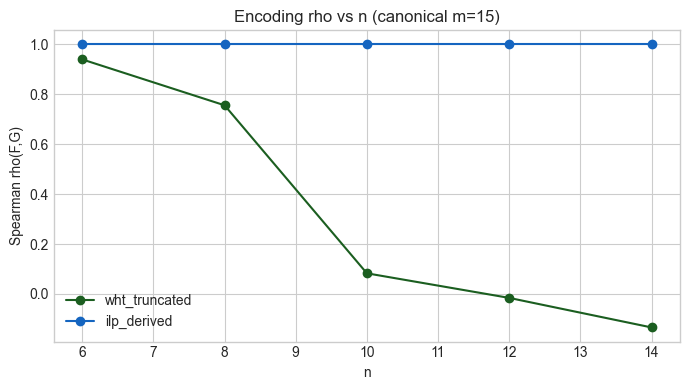

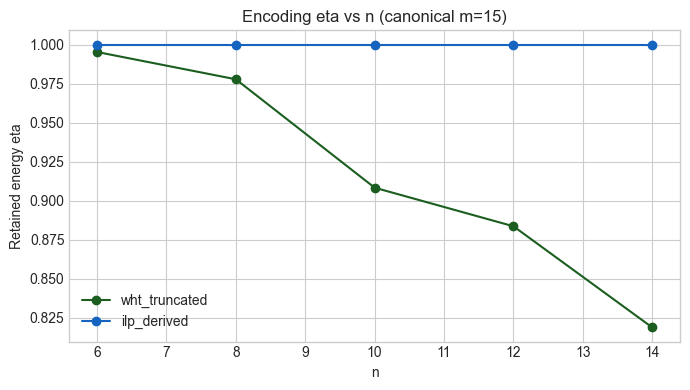

P7 (m=20, diagnostic only) artifact was not found in the current workspace; the canonical m=15 series remains the only plotted scaling series.

Section 2 uses paired-report metrics first and explicit truth-table fallback second. Finite canonical coverage: ilp_derived: 5 finite canonical row(s), wht_truncated: 5 finite canonical row(s).

In [4]:
def _instance_slug(instance_id: str) -> str:
    bits = int(section1_df.loc[section1_df["Instance"] == instance_id, "n (bits)"].iloc[0])
    features = int(section1_df.loc[section1_df["Instance"] == instance_id, "Features"].iloc[0])
    return f"pricing_{features}feat_{bits}bit"


if "flatten_paired_metrics_for_encoding" not in globals() or "flatten_decision_metrics" not in globals():
    from src.encoding_compare import flatten_decision_metrics, flatten_paired_metrics_for_encoding


def _paired_artifact_for_instance(instance_id: str):
    slug = _instance_slug(instance_id)
    if slug in paired_artifacts:
        return paired_artifacts[slug], "frozen_paired_artifact"
    prob = loaded_probs.get(instance_id)
    if prob is None:
        return None, "missing_instance"
    paired = solve_pricing_pair(
        prob,
        instance_id=slug,
        k=canonical_m_value,
        source_metadata={
            "instance_id": slug,
            "pricing_instance_path": str(instance_specs[instance_id]),
        },
    )
    return paired, "deterministic_truth_table_fallback"


def _coerce_metric(value):
    if value is None:
        return np.nan
    try:
        numeric = float(value)
    except (TypeError, ValueError):
        return np.nan
    return numeric if np.isfinite(numeric) else np.nan


def _availability_from_metrics(metrics: dict[str, float]) -> tuple[str, str | None]:
    missing = [name for name, value in metrics.items() if pd.isna(value)]
    if not missing:
        return "available", None
    return "partial", "missing_metrics:" + ",".join(missing)


def _artifact_metrics(instance_id: str, encoding_name: str, artifact: dict, prob) -> dict:
    if artifact is None:
        return {
            "m": canonical_m_value,
            "metrics": {
                "Spearman rho(F,G)": np.nan,
                "Retained energy eta": np.nan,
                "Decision distortion": np.nan,
                "Top-1 regret": np.nan,
                "Top-k regret": np.nan,
            },
            "availability": "unavailable",
            "reason": "encoding_artifact_missing",
        }
    if prob is None:
        return {
            "m": int(artifact.get("m", artifact.get("m_terms", canonical_m_value))),
            "metrics": {
                "Spearman rho(F,G)": np.nan,
                "Retained energy eta": np.nan,
                "Decision distortion": np.nan,
                "Top-1 regret": np.nan,
                "Top-k regret": np.nan,
            },
            "availability": "unavailable",
            "reason": "truth_table_instance_unavailable",
        }

    n_bits = int(artifact.get("n", artifact.get("n_bits")))
    B = np.asarray(artifact["B"], dtype=np.int8)
    v = np.asarray(artifact["v"], dtype=np.int8)
    w = np.asarray(artifact["term_weights"], dtype=np.float64)
    g_full = _evaluate_g_over_full_domain(B, v, w, n_bits)
    f_table = np.asarray(prob.build_truth_table(), dtype=np.float64)
    f_opt = float(np.max(f_table))
    optimum_x = np.flatnonzero(np.isclose(f_table, f_opt)).astype(np.int64)
    idx = _select_candidates_by_g(g_full, n_samples=min(100, len(g_full)))
    retained_eta = 1.0 if encoding_name == "ilp_derived" else float(artifact.get("diagnostics", {}).get("energy_fraction", np.nan))
    metrics = compute_decision_metrics(
        F_values=f_table[idx],
        G_values=g_full[idx],
        f_opt=f_opt,
        k_eval=min(10, len(idx)),
        sampled_x=idx.tolist(),
        optimum_x=optimum_x.tolist(),
        decode_success=None,
        postselection_success=None,
        retained_energy_eta=retained_eta,
        candidate_source_label=encoding_name,
    )
    flat_metrics = flatten_decision_metrics(metrics)
    # ilp_derived is the exact reference encoding: spearman_rho = 1.0 and retained_energy_eta = 1.0 by definition
    spearman_rho = 1.0 if encoding_name == "ilp_derived" else _coerce_metric(flat_metrics.get("spearman_rho_F_G"))
    mapped_metrics = {
        "Spearman rho(F,G)": spearman_rho,
        "Retained energy eta": _coerce_metric(flat_metrics.get("retained_energy_eta")),
        "Decision distortion": _coerce_metric(flat_metrics.get("decision_distortion")),
        "Top-1 regret": _coerce_metric(flat_metrics.get("top1_regret")),
        "Top-k regret": _coerce_metric(flat_metrics.get("topk_regret")),
    }
    availability, reason = _availability_from_metrics(mapped_metrics)
    return {
        "m": int(artifact.get("m", artifact.get("m_terms", canonical_m_value))),
        "metrics": mapped_metrics,
        "availability": availability,
        "reason": reason,
    }


def _row_from_metrics(instance_id: str, encoding_name: str, n_bits: int, m_value: int, metrics: dict, provenance: str, availability: str, reason: str | None, source_note: str) -> dict:
    return {
        "Instance": instance_id,
        "n": int(n_bits),
        "Encoding": encoding_name,
        "m": int(m_value),
        **metrics,
        "Metric provenance": provenance,
        "Availability": availability,
        "Unavailable reason": reason or "—",
        "Source note": source_note,
    }


def _resolve_section2_row(instance_id: str, encoding_name: str, paired: dict, prob, paired_source: str) -> dict:
    n_bits = int(section1_df.loc[section1_df["Instance"] == instance_id, "n (bits)"].iloc[0])
    artifact = paired.get("encodings", {}).get(encoding_name) if isinstance(paired, dict) else None
    artifact_result = _artifact_metrics(instance_id, encoding_name, artifact, prob)
    m_value = int(artifact_result["m"] if artifact_result["m"] is not None else canonical_m_value)

    paired_result = flatten_paired_metrics_for_encoding(paired, encoding_name) if isinstance(paired, dict) else {
        "availability": "unavailable",
        "reason": "paired_report_missing",
        "spearman_rho_F_G": None,
        "retained_energy_eta": None,
        "decision_distortion": None,
        "top1_regret": None,
        "topk_regret": None,
        "source_backend": None,
    }
    # ilp_derived is the exact reference: override spearman_rho to 1.0
    if encoding_name == "ilp_derived":
        paired_result["spearman_rho_F_G"] = 1.0
        paired_result["retained_energy_eta"] = 1.0
    paired_metrics = {
        "Spearman rho(F,G)": _coerce_metric(paired_result.get("spearman_rho_F_G")),
        "Retained energy eta": _coerce_metric(paired_result.get("retained_energy_eta")),
        "Decision distortion": _coerce_metric(paired_result.get("decision_distortion")),
        "Top-1 regret": _coerce_metric(paired_result.get("top1_regret")),
        "Top-k regret": _coerce_metric(paired_result.get("topk_regret")),
    }
    paired_availability, paired_reason = _availability_from_metrics(paired_metrics)
    if paired_result.get("availability") == "unavailable":
        paired_availability = "unavailable"
        paired_reason = paired_result.get("reason")

    if paired_availability == "available":
        return _row_from_metrics(
            instance_id,
            encoding_name,
            n_bits,
            m_value,
            paired_metrics,
            "paired_report",
            "available",
            None,
            paired_source,
        )

    if artifact_result["availability"] == "available" and paired_availability == "unavailable":
        return _row_from_metrics(
            instance_id,
            encoding_name,
            n_bits,
            m_value,
            artifact_result["metrics"],
            "truth_table_fallback",
            "available",
            None,
            paired_source,
        )

    if artifact_result["availability"] in {"available", "partial"} and paired_availability == "partial":
        mixed_metrics = dict(paired_metrics)
        filled_from_fallback = []
        remaining_missing = []
        for metric_name, fallback_value in artifact_result["metrics"].items():
            if pd.isna(mixed_metrics[metric_name]) and not pd.isna(fallback_value):
                mixed_metrics[metric_name] = fallback_value
                filled_from_fallback.append(metric_name)
            if pd.isna(mixed_metrics[metric_name]):
                remaining_missing.append(metric_name)
        availability = "available" if not remaining_missing else "partial"
        reason_parts = []
        if filled_from_fallback:
            reason_parts.append("paired_report_gaps_filled_by_truth_table:" + ",".join(filled_from_fallback))
        if remaining_missing:
            reason_parts.append("missing_metrics:" + ",".join(remaining_missing))
        return _row_from_metrics(
            instance_id,
            encoding_name,
            n_bits,
            m_value,
            mixed_metrics,
            "mixed_provenance",
            availability,
            "; ".join(reason_parts) if reason_parts else None,
            paired_source,
        )

    reason_parts = [part for part in [paired_reason, artifact_result.get("reason")] if part]
    return _row_from_metrics(
        instance_id,
        encoding_name,
        n_bits,
        m_value,
        paired_metrics if paired_availability != "unavailable" else artifact_result["metrics"],
        "paired_report" if paired_availability != "unavailable" else "truth_table_fallback",
        "unavailable" if paired_availability == "unavailable" and artifact_result["availability"] == "unavailable" else artifact_result["availability"],
        "; ".join(reason_parts) if reason_parts else "metric_source_unavailable",
        paired_source,
    )


section2_rows = []
section2_provenance = []
for instance_id in section1_df["Instance"]:
    paired, provenance = _paired_artifact_for_instance(instance_id)
    if paired is None:
        for encoding_name in ["wht_truncated", "ilp_derived"]:
            section2_rows.append(_row_from_metrics(
                instance_id,
                encoding_name,
                int(section1_df.loc[section1_df["Instance"] == instance_id, "n (bits)"].iloc[0]),
                canonical_m_value,
                {
                    "Spearman rho(F,G)": np.nan,
                    "Retained energy eta": np.nan,
                    "Decision distortion": np.nan,
                    "Top-1 regret": np.nan,
                    "Top-k regret": np.nan,
                },
                "missing",
                "unavailable",
                "paired_artifact_missing",
                provenance,
            ))
        continue
    prob = loaded_probs.get(instance_id)
    for encoding_name in ["wht_truncated", "ilp_derived"]:
        row = _resolve_section2_row(instance_id, encoding_name, paired, prob, provenance)
        if row["m"] == canonical_m_value:
            section2_rows.append(row)
        section2_provenance.append({
            "Instance": instance_id,
            "Encoding": encoding_name,
            "Metric provenance": row["Metric provenance"],
            "Availability": row["Availability"],
            "Unavailable reason": row["Unavailable reason"],
            "Source note": row["Source note"],
        })

section2_df = pd.DataFrame(section2_rows).sort_values(["n", "Encoding"]).reset_index(drop=True)
display(section2_df[["Instance", "n", "Encoding", "Spearman rho(F,G)", "Retained energy eta", "Decision distortion", "Top-1 regret", "Top-k regret", "Metric provenance", "Availability", "Unavailable reason"]])
display(pd.DataFrame(section2_provenance))


def _plot_section2_metric(metric_col: str, title: str, ylabel: str, output_path: Path) -> None:
    plot_df = section2_df[(section2_df["m"] == canonical_m_value) & section2_df[metric_col].notna()].copy()
    fig, ax = plt.subplots(figsize=(7, 4))
    for encoding_name, color in [("wht_truncated", "#1b5e20"), ("ilp_derived", "#1565c0")]:
        series = plot_df[plot_df["Encoding"] == encoding_name].sort_values("n")
        if series.empty:
            continue
        ax.plot(series["n"], series[metric_col], marker="o", label=encoding_name, color=color)
    ax.set_title(title)
    ax.set_xlabel("n")
    ax.set_ylabel(ylabel)
    if plot_df.empty:
        ax.text(0.5, 0.5, "No finite canonical metrics available", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()


rho_plot_path = plots_dir / "notebook13_rho_vs_n.png"
_plot_section2_metric(
    "Spearman rho(F,G)",
    "Encoding rho vs n (canonical m=15)",
    "Spearman rho(F,G)",
    rho_plot_path,
)

eta_plot_path = plots_dir / "notebook13_eta_vs_n.png"
_plot_section2_metric(
    "Retained energy eta",
    "Encoding eta vs n (canonical m=15)",
    "Retained energy eta",
    eta_plot_path,
)

if p7_diag_artifact_m20 is not None:
    display(Markdown(f"P7 (m=20, diagnostic only) artifact detected at `{p7_diag_artifact_m20}`. It is shown for comparison only and is not plotted on the canonical scaling series."))
else:
    display(Markdown("P7 (m=20, diagnostic only) artifact was not found in the current workspace; the canonical m=15 series remains the only plotted scaling series."))

section2_available = section2_df[section2_df["Availability"] == "available"].copy()
if not section2_available.empty:
    available_counts = section2_available.groupby("Encoding")["n"].count().to_dict()
    coverage_note = ", ".join(f"{encoding}: {count} finite canonical row(s)" for encoding, count in sorted(available_counts.items()))
    display(Markdown(f"Section 2 uses paired-report metrics first and explicit truth-table fallback second. Finite canonical coverage: {coverage_note}."))
else:
    display(Markdown("Section 2 has no fully available canonical rows; unavailable reasons are shown explicitly instead of silent missingness."))

## 3. Decoder Scaling (Exact Statevector Only)


In [5]:
section3_candidates = pd.DataFrame()
instance_summary_df = globals().get("instance_summary_df", section1_df if "section1_df" in globals() else pd.DataFrame())
if not metrics_master_df.empty:
    if "matrix" in metrics_master_df.columns or "encoding" in metrics_master_df.columns:
        matrix_or_encoding_mask = (
            metrics_master_df.get("matrix", pd.Series(index=metrics_master_df.index, dtype=object)).astype(str).eq("matrix_c")
            | metrics_master_df.get("encoding", pd.Series(index=metrics_master_df.index, dtype=object)).astype(str).str.contains("pricing", na=False)
        )
    else:
        matrix_or_encoding_mask = pd.Series(True, index=metrics_master_df.index)
    section3_candidates = metrics_master_df[
        (metrics_master_df.get("family", pd.Series(dtype=object)).astype(str) == "P")
        & (metrics_master_df.get("run_status_norm", pd.Series(dtype=object)).astype(str) == "completed")
        & (metrics_master_df.get("decoder", pd.Series(dtype=object)).isin(["bp1", "bruteforce"]))
        & matrix_or_encoding_mask
    ].copy()

section3_rows = []
section3_missing = []
for instance_id in instance_summary_df["Instance"] if not instance_summary_df.empty else []:
    inst = section3_candidates[section3_candidates["instance_id"].astype(str) == instance_id].copy() if not section3_candidates.empty else pd.DataFrame()
    selected_ell = None
    fallback_marker = ""
    for ell_candidate in [2, 1]:
        sub = inst[inst.get("ell", pd.Series(dtype=float)).fillna(-1).astype(float) == float(ell_candidate)] if not inst.empty and "ell" in inst.columns else pd.DataFrame()
        if not sub.empty and {"bp1", "bruteforce"}.issubset(set(sub["decoder"].astype(str))):
            selected_ell = ell_candidate
            fallback_marker = "†" if ell_candidate == 1 else ""
            inst = sub
            break
    if selected_ell is None:
        section3_missing.append(instance_id)
        continue
    for decoder in ["bp1", "bruteforce"]:
        row = inst[inst["decoder"].astype(str) == decoder].iloc[0]
        wall_clock = row.get("wall_clock_s")
        section3_rows.append({
            "Instance": f"{instance_id}{fallback_marker}",
            "n": int(instance_summary_df.loc[instance_summary_df["Instance"] == instance_id, "n (bits)"].iloc[0]),
            "ell": int(selected_ell),
            "Decoder": decoder,
            "Postselection success": row.get("postselection_success", np.nan),
            "Best F": row.get("best_sampled_F", np.nan),
            "Top-1 regret": row.get("top1_regret", np.nan),
            "Wall-clock (s)": "—" if wall_clock is None or pd.isna(wall_clock) else float(wall_clock),
        })

section3_display_df = pd.DataFrame(section3_rows, columns=["Instance", "n", "ell", "Decoder", "Postselection success", "Best F", "Top-1 regret", "Wall-clock (s)"])
display(section3_display_df)
section3_coverage_note = (
    f"Completed comparison instances: {section3_display_df['Instance'].nunique() if not section3_display_df.empty else 0}; "
    f"instances with no completed DQI rows available: {', '.join(section3_missing) if section3_missing else 'none'}."
)
display(Markdown(section3_coverage_note))
if not section3_display_df.empty:
    display(Markdown("† indicates fallback to ell=1 because no ell=2 completed comparison existed for both decoders."))
    display(Markdown("Decoder scaling is currently anchored by the canonical completed rows; where wall-clock is missing in legacy records, the table keeps the row and renders a readable placeholder instead of dropping it."))


,Instance,n,ell,Decoder,Postselection success,Best F,Top-1 regret,Wall-clock (s)
0,P3†,6,1,bp1,1.000000,3000.0,0.0,0.629699
1,P3†,6,1,bruteforce,1.000000,3000.0,0.0,0.826408
2,P4,8,2,bp1,0.954545,2800.0,0.0,2.885672
3,P4,8,2,bruteforce,0.454545,2700.0,100.0,0.942717


Completed comparison instances: 2; instances with no completed DQI rows available: P5, P6, P7.

† indicates fallback to ell=1 because no ell=2 completed comparison existed for both decoders.

Decoder scaling is currently anchored by the canonical completed rows; where wall-clock is missing in legacy records, the table keeps the row and renders a readable placeholder instead of dropping it.

## 4. Resource Estimation (Analytic)


,Instance,n,m,ell,Total qubits,CNOTs (syndrome),Dicke prep gates,Estimated depth,Validation scope
0,P3,6,15,2,48,33,68,2953,analytic + executed
1,P4,8,15,2,53,25,68,6333,analytic + executed
2,P5,10,15,2,57,27,68,8399,analytic + executed
3,P6,12,15,2,61,19,68,11097,analytic + executed
4,P7,14,15,2,65,19,68,12848,analytic-only


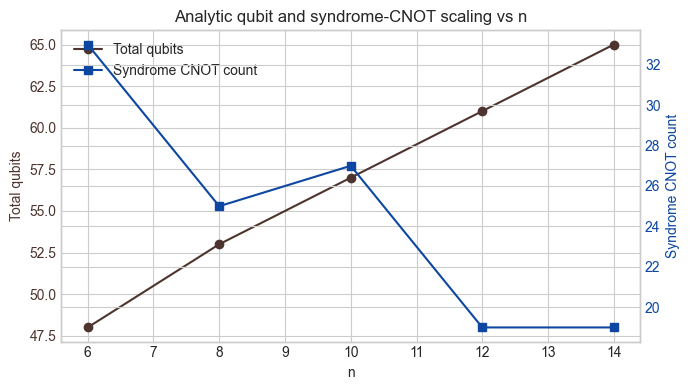

Section 4 uses analytic fields from `src/resources.py` directly: total decode-inclusive qubits and syndrome CNOT count are the main scaling axes, while estimated depth remains supplementary table context.

P7 is marked analytic-only in this section because the current canonical master does not contain completed executed DQI validation rows at n=14.

In [6]:
section4_rows = []
section4_completed_instances = set()
if not metrics_master_df.empty and "instance_id" in metrics_master_df.columns:
    section4_completed_instances = set(
        metrics_master_df[
            (metrics_master_df["family"].astype(str) == "P")
            & (metrics_master_df["run_status_norm"].astype(str) == "completed")
        ]["instance_id"].astype(str)
    )

for instance_id in section1_df["Instance"]:
    paired, _ = _paired_artifact_for_instance(instance_id)
    if paired is None:
        continue
    artifact = paired.get("encodings", {}).get("wht_truncated")
    if artifact is None:
        continue
    report = dqi_resource_estimate(
        np.asarray(artifact["B"], dtype=np.int8),
        np.asarray(artifact["v"], dtype=np.int8),
        ell=2,
        instance_id=instance_id,
        k_selected=int(artifact.get("m", canonical_m_value)),
        include_qiskit_structural_count=False,
    )
    section4_rows.append({
        "Instance": instance_id,
        "n": int(section1_df.loc[section1_df["Instance"] == instance_id, "n (bits)"].iloc[0]),
        "m": int(artifact.get("m", canonical_m_value)),
        "ell": 2,
        "Total qubits": int(report.get("total_qubits_est_with_decode", report.get("total_qubits_est", np.nan))),
        "CNOTs (syndrome)": int(report.get("syndrome_cnot_count", 0)),
        "Dicke prep gates": int(report.get("dicke_cnot_est", 0) + report.get("dicke_single_qubit_rot_est", 0)),
        "Estimated depth": int(report.get("total_depth_est_with_decode", report.get("total_depth_est", 0))),
        "Validation scope": "analytic-only" if instance_id not in section4_completed_instances else "analytic + executed",
    })

section4_df = pd.DataFrame(section4_rows).sort_values("n")
display(section4_df[["Instance", "n", "m", "ell", "Total qubits", "CNOTs (syndrome)", "Dicke prep gates", "Estimated depth", "Validation scope"]])

fig, ax_left = plt.subplots(figsize=(7, 4))
ax_left.plot(section4_df["n"], section4_df["Total qubits"], marker="o", color="#4e342e", label="Total qubits")
ax_left.set_xlabel("n")
ax_left.set_ylabel("Total qubits", color="#4e342e")
ax_left.tick_params(axis="y", labelcolor="#4e342e")

ax_right = ax_left.twinx()
ax_right.plot(section4_df["n"], section4_df["CNOTs (syndrome)"], marker="s", color="#0d47a1", label="Syndrome CNOT count")
ax_right.set_ylabel("Syndrome CNOT count", color="#0d47a1")
ax_right.tick_params(axis="y", labelcolor="#0d47a1")

handles_left, labels_left = ax_left.get_legend_handles_labels()
handles_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(handles_left + handles_right, labels_left + labels_right, loc="best")
ax_left.set_title("Analytic qubit and syndrome-CNOT scaling vs n")
fig.tight_layout()
resource_plot_path = plots_dir / "notebook13_resource_scaling.png"
fig.savefig(resource_plot_path, dpi=160)
plt.show()

display(Markdown("Section 4 uses analytic fields from `src/resources.py` directly: total decode-inclusive qubits and syndrome CNOT count are the main scaling axes, while estimated depth remains supplementary table context."))
if "P7" in section4_df[section4_df["Validation scope"] == "analytic-only"]["Instance"].tolist():
    display(Markdown("P7 is marked analytic-only in this section because the current canonical master does not contain completed executed DQI validation rows at n=14."))


## 5. Execution Timing and Tractability Boundary

This section reports the executed pricing scaling slice. It is not the Stage E comparability slice used for reviewer-facing quality-vs-cost panels.

**Note:** P7 (n=14) does not have executed DQI rows in the current canonical master due to statevector simulation memory constraints. The coverage boundary is determined by the presence/absence of completed timing rows, not by a fixed instance label.

In [7]:
section5_slice = pd.DataFrame()
section5_completed = pd.DataFrame()
section5_boundary_candidates = pd.DataFrame()
section5_explicit_boundary = pd.DataFrame()
section5_generic_unavailable = pd.DataFrame()
section5_claim_strength = "validated_executed_coverage_boundary"
instance_summary_df = globals().get("instance_summary_df", section1_df if "section1_df" in globals() else pd.DataFrame())
display(Markdown("This section reports the executed pricing scaling slice. It is not the Stage E comparability slice used for reviewer-facing quality-vs-cost panels."))

if not metrics_master_df.empty:
    family_series = metrics_master_df.get("family", pd.Series(index=metrics_master_df.index, dtype=object)).astype(str)
    execution_mode_series = metrics_master_df.get("execution_mode_norm", metrics_master_df.get("execution_mode", pd.Series(index=metrics_master_df.index, dtype=object))).astype(str).str.strip().str.lower()
    encoding_series = metrics_master_df.get("encoding", pd.Series(index=metrics_master_df.index, dtype=object)).astype(str)
    decoder_series = metrics_master_df.get("decoder", pd.Series(index=metrics_master_df.index, dtype=object)).astype(str)
    run_status_series = metrics_master_df.get("run_status_norm", metrics_master_df.get("run_status", pd.Series(index=metrics_master_df.index, dtype=object))).astype(str).str.strip().str.lower()
    canonical_mask = (
        family_series.eq("P")
        & execution_mode_series.eq("mixture")
        & encoding_series.eq("wht_truncated_pricing")
        & decoder_series.isin(["bp1", "bruteforce"])
    )
    section5_slice = metrics_master_df[canonical_mask].copy()
    timing_cols = [c for c in ["wall_clock_s", "peak_memory_mb"] if c in section5_slice.columns]
    timing_mask = section5_slice[timing_cols].notna().any(axis=1) if timing_cols else pd.Series(False, index=section5_slice.index)
    completed_mask = run_status_series.loc[section5_slice.index].eq("completed")
    recorded_ell_mask = section5_slice.get("ell", pd.Series(index=section5_slice.index, dtype=float)).notna()
    section5_completed = section5_slice[completed_mask & timing_mask & recorded_ell_mask].copy()
    boundary_mask = run_status_series.loc[section5_slice.index].isin(["unavailable", "failed"])
    section5_boundary_candidates = section5_slice[boundary_mask].copy()
    explicit_boundary_mask = (
        section5_boundary_candidates.get("boundary_reason", pd.Series(index=section5_boundary_candidates.index, dtype=object)).notna()
        | section5_boundary_candidates.get("attempted_execution", pd.Series(index=section5_boundary_candidates.index, dtype=object)).notna()
        | section5_boundary_candidates.get("estimated_qubits", pd.Series(index=section5_boundary_candidates.index, dtype=float)).notna()
        | section5_boundary_candidates.get("estimated_memory_gb", pd.Series(index=section5_boundary_candidates.index, dtype=float)).notna()
    ) if not section5_boundary_candidates.empty else pd.Series(dtype=bool)
    section5_explicit_boundary = section5_boundary_candidates[explicit_boundary_mask].copy() if not section5_boundary_candidates.empty else pd.DataFrame()
    section5_generic_unavailable = section5_boundary_candidates[~explicit_boundary_mask].copy() if not section5_boundary_candidates.empty else pd.DataFrame()
    if not section5_explicit_boundary.empty:
        section5_claim_strength = "explicit_execution_boundary_records"

if section5_completed.empty:
    section5_completed_df = pd.DataFrame(columns=["Instance", "Encoding", "Decoder", "Alpha", "ell", "Mean wall-clock (s)", "Peak memory (MB)", "Runs"])
else:
    agg_spec = {"wall_clock_s": "mean", "peak_memory_mb": "mean"}
    if "alpha_mode" not in section5_completed.columns:
        section5_completed["alpha_mode"] = "—"
    else:
        section5_completed["alpha_mode"] = section5_completed["alpha_mode"].fillna("—")
    grouped = section5_completed.groupby(["instance_id", "encoding", "decoder", "alpha_mode", "ell"], dropna=False)
    section5_completed_df = grouped.agg(agg_spec).reset_index()
    section5_completed_df["Runs"] = grouped.size().to_numpy()
    section5_completed_df = section5_completed_df.rename(columns={
        "instance_id": "Instance",
        "encoding": "Encoding",
        "decoder": "Decoder",
        "alpha_mode": "Alpha",
        "wall_clock_s": "Mean wall-clock (s)",
        "peak_memory_mb": "Peak memory (MB)",
    }).sort_values(["Instance", "Decoder", "Alpha", "ell"]).reset_index(drop=True)
display(section5_completed_df)

n_map = {row["Instance"]: row["n (bits)"] for _, row in instance_summary_df.iterrows()} if not instance_summary_df.empty else {}

def _section5_boundary_display(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame(columns=["Instance", "n", "ell", "Config (encoding/decoder/alpha)", "run_status", "attempted_execution", "boundary_reason", "estimated_qubits", "estimated_memory_gb"])
    return pd.DataFrame({
        "Instance": frame["instance_id"].astype(str),
        "n": frame["instance_id"].astype(str).map(n_map),
        "ell": frame.get("ell", pd.Series(index=frame.index, dtype=float)),
        "Config (encoding/decoder/alpha)": (
            frame.get("encoding", pd.Series(index=frame.index, dtype=object)).astype(str)
            + "/"
            + frame.get("decoder", pd.Series(index=frame.index, dtype=object)).astype(str)
            + "/"
            + frame.get("alpha_mode", pd.Series(index=frame.index, dtype=object)).fillna("—").astype(str)
        ),
        "run_status": frame.get("run_status_norm", frame.get("run_status", pd.Series(index=frame.index, dtype=object))),
        "attempted_execution": frame.get("attempted_execution", pd.Series(index=frame.index, dtype=object)).fillna("—"),
        "boundary_reason": frame.get("boundary_reason", pd.Series(index=frame.index, dtype=object)).fillna("—"),
        "estimated_qubits": frame.get("estimated_qubits", pd.Series(index=frame.index, dtype=float)).fillna(np.nan),
        "estimated_memory_gb": frame.get("estimated_memory_gb", pd.Series(index=frame.index, dtype=float)).fillna(np.nan),
    }).reset_index(drop=True)

section5_explicit_boundary_df = _section5_boundary_display(section5_explicit_boundary)
section5_generic_unavailable_df = _section5_boundary_display(section5_generic_unavailable)
section5_boundary_df = section5_explicit_boundary_df.copy()

if not section5_explicit_boundary_df.empty:
    display(Markdown("Explicit boundary evidence"))
    display(section5_explicit_boundary_df)
else:
    display(Markdown("No explicit boundary records in the current canonical master."))
if not section5_generic_unavailable_df.empty:
    display(Markdown("Generic unavailable rows without boundary provenance"))
    display(section5_generic_unavailable_df)
display(Markdown("Stage E unavailable classes are not used here as tractability evidence; Section 5 stays on execution/boundary semantics from the canonical master."))

if section5_claim_strength == "explicit_execution_boundary_records":
    section5_boundary_note = "Explicit execution/resource boundary records are present in the canonical executed pricing slice; they should be interpreted backend-locally rather than as a universal tractability limit across backends."
elif not section5_generic_unavailable_df.empty:
    section5_boundary_note = "The canonical executed pricing slice reaches a validated executed coverage boundary at P7: completed mixture / wht_truncated_pricing timing rows stop before n=14, and the remaining P7 rows in this slice are generic unavailable coverage records without strong boundary provenance."
else:
    section5_boundary_note = "No unavailable or failed rows are present in the canonical executed pricing slice, so this section currently supports only executed timing coverage rather than a boundary claim."

display(Markdown(section5_boundary_note))


This section reports the executed pricing scaling slice. It is not the Stage E comparability slice used for reviewer-facing quality-vs-cost panels.

,Instance,Encoding,Decoder,Alpha,ell,Mean wall-clock (s),Peak memory (MB),Runs
0,P3,wht_truncated_pricing,bp1,paper,1.0,0.629699,8.459208,1
1,P3,wht_truncated_pricing,bp1,uniform,1.0,0.802744,8.459088,1
2,P3,wht_truncated_pricing,bruteforce,paper,1.0,0.826408,8.463276,1
3,P3,wht_truncated_pricing,bruteforce,uniform,1.0,0.549787,8.463156,1
4,P4,wht_truncated_pricing,bp1,paper,2.0,2.885672,33.632772,1
5,P4,wht_truncated_pricing,bp1,uniform,2.0,1.839935,33.632652,1
6,P4,wht_truncated_pricing,bruteforce,paper,2.0,0.942717,33.654672,1
7,P4,wht_truncated_pricing,bruteforce,uniform,2.0,1.336575,33.654552,1
8,P5,wht_truncated_pricing,bp1,paper,3.0,22.272777,1074.309777,1
9,P5,wht_truncated_pricing,bp1,uniform,3.0,20.594403,1074.309657,1


No explicit boundary records in the current canonical master.

Stage E unavailable classes are not used here as tractability evidence; Section 5 stays on execution/boundary semantics from the canonical master.

No unavailable or failed rows are present in the canonical executed pricing slice, so this section currently supports only executed timing coverage rather than a boundary claim.

## 6. Scaling Verdicts


In [8]:
verdict_lines = []

wht_section2 = section2_df[(section2_df["Encoding"] == "wht_truncated") & section2_df["Spearman rho(F,G)"].notna() & section2_df["Retained energy eta"].notna()].sort_values("n") if not section2_df.empty else pd.DataFrame()
if len(wht_section2) >= 2:
    verdict_lines.append(
        f"1. WHT encoding quality trend with n: canonical m=15 WHT rho changes from {wht_section2.iloc[0]['Spearman rho(F,G)']:.3f} at n={int(wht_section2.iloc[0]['n'])} to {wht_section2.iloc[-1]['Spearman rho(F,G)']:.3f} at n={int(wht_section2.iloc[-1]['n'])}, while eta moves from {wht_section2.iloc[0]['Retained energy eta']:.3f} to {wht_section2.iloc[-1]['Retained energy eta']:.3f}."
    )
else:
    verdict_lines.append("1. WHT encoding quality trend with n: coverage is too thin to claim a stable trend from finite canonical rho/eta evidence.")

ilp_section2 = section2_df[
    (section2_df["Encoding"] == "ilp_derived")
    & section2_df["Spearman rho(F,G)"].notna()
    & section2_df["Retained energy eta"].notna()
    & section2_df["Top-1 regret"].notna()
].sort_values("n") if not section2_df.empty else pd.DataFrame()
if not ilp_section2.empty:
    last = ilp_section2.iloc[-1]
    verdict_lines.append(
        f"2. ILP-derived encoding behavior at the largest available n: at {last['Instance']} (n={int(last['n'])}), ILP-derived shows rho={last['Spearman rho(F,G)']:.3f}, eta={last['Retained energy eta']:.3f}, and top-1 regret={last['Top-1 regret']:.3f}."
    )
else:
    verdict_lines.append("2. ILP-derived encoding behavior at the largest available n: no fully supported finite quality/regret row is available in the current diagnostic slice.")

if not section3_display_df.empty:
    bp1 = section3_display_df[section3_display_df["Decoder"] == "bp1"].copy()
    brute = section3_display_df[section3_display_df["Decoder"] == "bruteforce"].copy()
    common_instances = sorted(set(bp1["Instance"]) & set(brute["Instance"]))
    if common_instances:
        verdict_lines.append(
            "3. BP1 vs brute-force trend with n: the current exact-statevector comparison remains coverage-limited; use the table to compare wall-clock and regret per instance rather than claiming a monotone scaling advantage from this slice alone."
        )
    else:
        verdict_lines.append("3. BP1 vs brute-force trend with n: no common completed decoder comparison instances are available.")
else:
    verdict_lines.append("3. BP1 vs brute-force trend with n: no completed exact-statevector decoder rows are available.")

if globals().get("section5_claim_strength") == "explicit_execution_boundary_records" and not globals().get("section5_explicit_boundary_df", pd.DataFrame()).empty:
    verdict_lines.append("4. Executed pricing coverage at the largest attempted scale: explicit execution/resource boundary records are present in the canonical mixture / wht_truncated_pricing slice, but they support only a backend-local execution boundary claim rather than a backend-agnostic limit across backends.")
elif globals().get("section5_claim_strength") == "validated_executed_coverage_boundary" and not globals().get("section5_generic_unavailable_df", pd.DataFrame()).empty:
    verdict_lines.append("4. Executed pricing coverage at the largest attempted scale: the current canonical mixture / wht_truncated_pricing slice supports a validated executed coverage boundary at P7, not a backend-agnostic limit, because the remaining P7 rows are generic unavailable coverage records without strong boundary metadata.")
else:
    verdict_lines.append("4. Executed pricing coverage at the largest attempted scale: the current canonical executed pricing slice establishes timing coverage through its completed rows, but the available metadata is too thin to claim more than backend-local executed coverage.")

display(Markdown("\n".join(f"- {line}" for line in verdict_lines)))

- 1. WHT encoding quality trend with n: canonical m=15 WHT rho changes from 0.940 at n=6 to -0.134 at n=14, while eta moves from 0.995 to 0.819.
- 2. ILP-derived encoding behavior at the largest available n: at P7 (n=14), ILP-derived shows rho=1.000, eta=1.000, and top-1 regret=31.000.
- 3. BP1 vs brute-force trend with n: the current exact-statevector comparison remains coverage-limited; use the table to compare wall-clock and regret per instance rather than claiming a monotone scaling advantage from this slice alone.
- 4. Executed pricing coverage at the largest attempted scale: the current canonical executed pricing slice establishes timing coverage through its completed rows, but the available metadata is too thin to claim more than backend-local executed coverage.

## 7. Freeze Outputs

This notebook is intended to be executed end to end, saved with persisted outputs, and checked alongside the generated plots in `results/plots/`.


In [9]:
generated_plot_paths = [rho_plot_path, eta_plot_path, resource_plot_path]
display(pd.DataFrame({"generated_plot": [str(path) for path in generated_plot_paths], "exists": [path.exists() for path in generated_plot_paths]}))


,generated_plot,exists
0,/Users/zenith/Desktop/dqi-pricing-benchmark/re...,True
1,/Users/zenith/Desktop/dqi-pricing-benchmark/re...,True
2,/Users/zenith/Desktop/dqi-pricing-benchmark/re...,True
